# SCENIC Analysis - Data Preprocessing

This notebook performs data preprocessing for SCENIC (Single-Cell Regulatory Network Inference and Clustering) analysis on single-cell RNA-seq data.

## Important Notes

- **This is the preprocessing notebook**. After completing this notebook, proceed to `pySCENIC-processing.ipynb` for SCENIC analysis.
- This template is configured for **mouse data (mm10)**. Adjust database paths and parameters for other species.
- **Preprocessing should follow single-cell best practices**. This workflow is based on the [Single-cell best practices guide](https://www.sc-best-practices.org/preamble.html) (Heumos, L., Schaar, A.C., Lance, C. et al., *Nat Rev Genet*, 2023).
- **Parameters in this notebook are dataset-specific**. The filtering thresholds, normalization parameters, and clustering resolution used here were optimized for this particular dataset. **Users should adjust these values based on their own data characteristics** by examining the diagnostic plots generated at each step.

## Preprocessing Workflow Overview

1. Data import
2. Merge multiple samples
3. Quality control and filtering
4. Preprocessing and normalization
5. Dimensionality reduction (PCA, UMAP)
6. Clustering
7. Batch effect assessment
8. Marker gene identification

## Output Files

This notebook generates:
- `pre_processing_results/processed_adata.h5ad` - Processed AnnData object with clustering and UMAP
- `pre_processing_results/merged_cleaned.loom` - Filtered loom file for SCENIC analysis

## References

- Aibar, S. et al. (2017). SCENIC: single-cell regulatory network inference and clustering. *Nature Methods*, 14(11), 1083-1086.
- Heumos, L., Schaar, A.C., Lance, C. et al. (2023). Best practices for single-cell analysis across modalities. *Nat Rev Genet*. https://doi.org/10.1038/s41576-023-00586-w


In [1]:
# Import required libraries
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import loompy as lp
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Set parallel processing (adjust based on available resources)
sc.settings.njobs = 20  # Number of parallel jobs for scanpy operations

warnings.filterwarnings('ignore')


## Step 1: Configure File Paths and Parameters

Set up file paths for input data, output directories, and analysis parameters.


In [ ]:
# Configure file paths and analysis parameters

wdir = os.getcwd()
print(f"Working directory: {wdir}")

# Input data configuration
sample_1 = "mouse_1"  
sample_2 = "mouse_2"

# TODO: Update these paths to match your actual data files
f_h5_path_mouse1 = f"{sample_1}/SC3_v3_NextGem_DI_CellPlex_Mouse_PBMC_10K_PBMCs_{sample_1}_count_sample_feature_bc_matrix.h5"
f_h5_path_mouse2 = f"{sample_2}/SC3_v3_NextGem_DI_CellPlex_Mouse_PBMC_10K_PBMCs_{sample_2}_count_sample_feature_bc_matrix.h5"

# Output file paths
output_dir = os.path.join(wdir, "pre_processing_results")
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

# AnnData object file path (for saving processed data)
f_anndata_path = os.path.join(output_dir, "processed_adata.h5ad")
print(f"AnnData output path: {f_anndata_path}")


## Step 2: Data Import and Write Unfiltered Loom Files

Import expression data for each mouse and write unfiltered datasets to individual loom files.


In [3]:
# Import expression data for Mouse 1
print(f"Reading Mouse 1 data from: {f_h5_path_mouse1}")
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Variable names are not unique")
    adata_mouse1 = sc.read_10x_h5(f_h5_path_mouse1)

adata_mouse1.var_names_make_unique()
adata_mouse1.obs['sample'] = sample_1
adata_mouse1.obs['mouse'] = sample_1

print(f"Mouse 1 data shape: {adata_mouse1.shape}")
print(f"Mouse 1 - Number of cells: {adata_mouse1.n_obs}")
print(f"Mouse 1 - Number of genes: {adata_mouse1.n_vars}")

# Import expression data for Mouse 2
print(f"\nReading Mouse 2 data from: {f_h5_path_mouse2}")
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Variable names are not unique")
    adata_mouse2 = sc.read_10x_h5(f_h5_path_mouse2)
adata_mouse2.var_names_make_unique()
adata_mouse2.obs['sample'] = sample_2
adata_mouse2.obs['mouse'] = sample_2

print(f"Mouse 2 data shape: {adata_mouse2.shape}")
print(f"Mouse 2 - Number of cells: {adata_mouse2.n_obs}")
print(f"Mouse 2 - Number of genes: {adata_mouse2.n_vars}")


Reading Mouse 1 data from: mouse_1/SC3_v3_NextGem_DI_CellPlex_Mouse_PBMC_10K_PBMCs_mouse_1_count_sample_feature_bc_matrix.h5
Mouse 1 data shape: (4598, 32285)
Mouse 1 - Number of cells: 4598
Mouse 1 - Number of genes: 32285

Reading Mouse 2 data from: mouse_2/SC3_v3_NextGem_DI_CellPlex_Mouse_PBMC_10K_PBMCs_mouse_2_count_sample_feature_bc_matrix.h5
Mouse 2 data shape: (5236, 32285)
Mouse 2 - Number of cells: 5236
Mouse 2 - Number of genes: 32285


In [ ]:
# Define output file paths for unfiltered loom files
f_loom_raw_mouse1 = os.path.join(output_dir, f"{sample_1}_raw.loom")
f_loom_raw_mouse2 = os.path.join(output_dir, f"{sample_2}_raw.loom")

# Write Mouse 1 unfiltered data to loom file
print(f"Writing Mouse 1 unfiltered data to: {f_loom_raw_mouse1}")

# Define row and column attributes for Loom format
# Row attributes: gene information
row_attrs_m1 = {
    "Gene": np.array(adata_mouse1.var.index),
}

# Column attributes: cell information
col_attrs_m1 = {
    "CellID": np.array(adata_mouse1.obs.index),
    "sample": np.array(adata_mouse1.obs['sample']),
    "mouse": np.array(adata_mouse1.obs['mouse']),
    "nGene": np.array(np.sum(adata_mouse1.X > 0, axis=1)).flatten(),
    "nUMI": np.array(np.sum(adata_mouse1.X, axis=1)).flatten(),
}

# Create Loom file (expression matrix must be transposed: genes x cells)
lp.create(f_loom_raw_mouse1, adata_mouse1.X.transpose(), row_attrs_m1, col_attrs_m1)
print(f"Created loom file: {f_loom_raw_mouse1}")
print(f"Loom file shape: {adata_mouse1.X.transpose().shape} (genes x cells)\n")

# Write Mouse 2 unfiltered data to loom file
print(f"Writing Mouse 2 unfiltered data to: {f_loom_raw_mouse2}")

row_attrs_m2 = {
    "Gene": np.array(adata_mouse2.var.index),
}

col_attrs_m2 = {
    "CellID": np.array(adata_mouse2.obs.index),
    "sample": np.array(adata_mouse2.obs['sample']),
    "mouse": np.array(adata_mouse2.obs['mouse']),
    "nGene": np.array(np.sum(adata_mouse2.X > 0, axis=1)).flatten(),
    "nUMI": np.array(np.sum(adata_mouse2.X, axis=1)).flatten(),
}

lp.create(f_loom_raw_mouse2, adata_mouse2.X.transpose(), row_attrs_m2, col_attrs_m2)
print(f"Created loom file: {f_loom_raw_mouse2}")
print(f"Loom file shape: {adata_mouse2.X.transpose().shape} (genes x cells)")


## Step 3: Merge Loom Raw Files

Merge the unfiltered loom files from both mice into a single merged loom file.


In [ ]:
# Define output file path for merged raw loom file
f_loom_raw_merged = os.path.join(output_dir, "merged_raw.loom")

# Merge AnnData objects first (easier to work with)
import warnings
print("Merging AnnData objects...")
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='.*X.dtype being converted.*')
    adata = adata_mouse1.concatenate(adata_mouse2, join='outer', index_unique='-', batch_key='sample')

# Ensure merged dataset has unique gene names (safety check)
adata.var_names_make_unique()

print(f"Merged data shape: {adata.shape}")
print(f"Total cells: {adata.n_obs}")
print(f"Total genes: {adata.n_vars}")
print(f"\nSample distribution:")
print(adata.obs['sample'].value_counts())

# Write merged unfiltered data to loom file
print(f"\nWriting merged unfiltered data to: {f_loom_raw_merged}")

row_attrs_merged = {
    "Gene": np.array(adata.var.index),
}

col_attrs_merged = {
    "CellID": np.array(adata.obs.index),
    "sample": np.array(adata.obs['sample']),
    "mouse": np.array(adata.obs['mouse']),
    "nGene": np.array(np.sum(adata.X > 0, axis=1)).flatten(),
    "nUMI": np.array(np.sum(adata.X, axis=1)).flatten(),
}

lp.create(f_loom_raw_merged, adata.X.transpose(), row_attrs_merged, col_attrs_merged)
print(f"Created merged loom file: {f_loom_raw_merged}")
print(f"Merged loom file shape: {adata.X.transpose().shape} (genes x cells)")


## Step 3.5: Inspect Merged Loom File

Check the merged loom file structure and contents.


In [ ]:
# Inspect the merged loom file
print("Inspecting merged loom file...")
print(f"Loom file path: {f_loom_raw_merged}\n")

# Open loom file in read mode
lf = lp.connect(f_loom_raw_merged, mode='r', validate=False)

# Basic information
print("=== Loom File Structure ===")
print(f"Shape: {lf.shape} (genes x cells)")
print(f"Number of genes (rows): {lf.shape[0]}")
print(f"Number of cells (columns): {lf.shape[1]}\n")


## Step 4: Generate Diagnostic Plots for Individual Samples (Pre-filtering)

Calculate quality control metrics and generate diagnostic plots for each mouse separately before merging.


Calculating QC metrics for individual samples...

=== mouse_1 ===
=== mouse_2 ===

Generating violin plots for mouse_1...


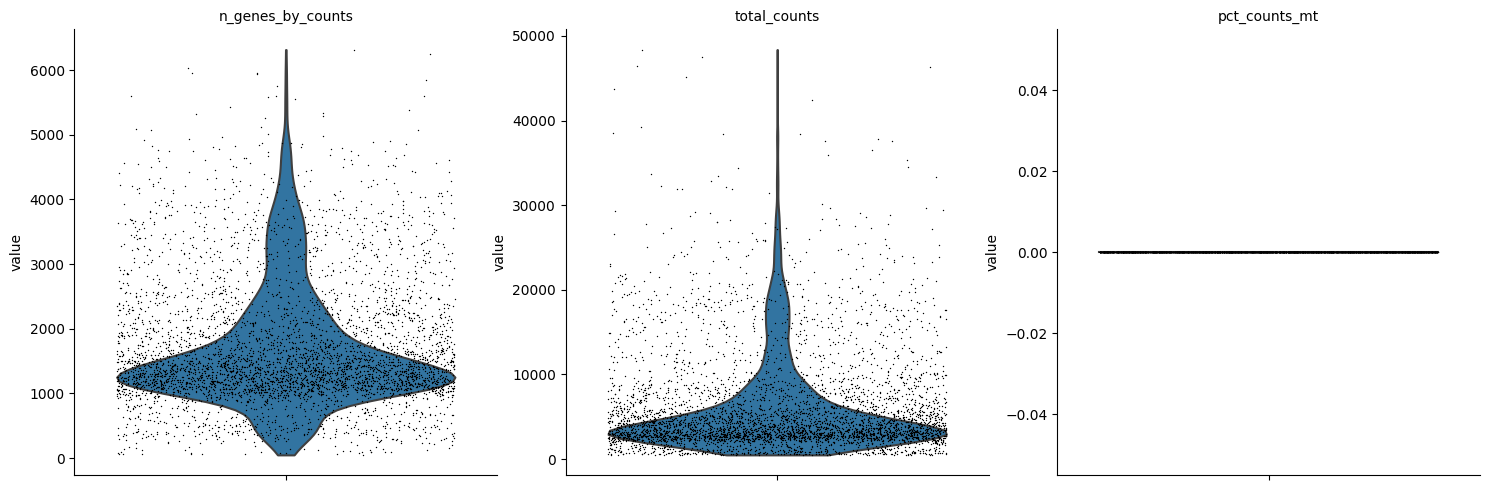


Generating violin plots for mouse_2...


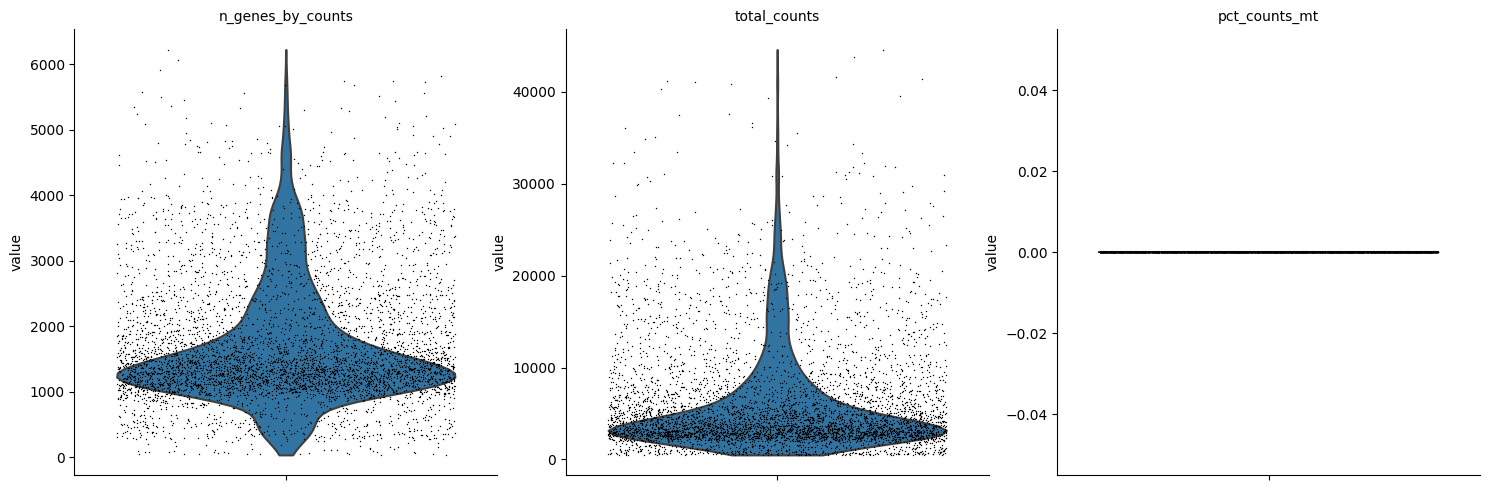

In [7]:
# Calculate QC metrics for individual samples before merging
print("Calculating QC metrics for individual samples...\n")

# Process Mouse 1
print(f"=== {sample_1} ===")
adata_mouse1.var['mt'] = adata_mouse1.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata_mouse1, percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(adata_mouse1, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Process Mouse 2
print(f"=== {sample_2} ===")
adata_mouse2.var['mt'] = adata_mouse2.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata_mouse2, percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(adata_mouse2, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Generate violin plots for Mouse 1
print(f"\nGenerating violin plots for {sample_1}...")
sc.pl.violin(adata_mouse1, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, show=False)
plt.savefig(os.path.join(output_dir, f'qc_plots_{sample_1}_violin.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Generate violin plots for Mouse 2
print(f"\nGenerating violin plots for {sample_2}...")
sc.pl.violin(adata_mouse2, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, show=False)
plt.savefig(os.path.join(output_dir, f'qc_plots_{sample_2}_violin.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()


## Step 4.5: Generate Diagnostic Plots for Combined Data (Pre-filtering)

Calculate quality control metrics and generate diagnostic plots for the merged dataset.


Calculating QC metrics for merged data...
Generating pre-filtering diagnostic plots for merged data...



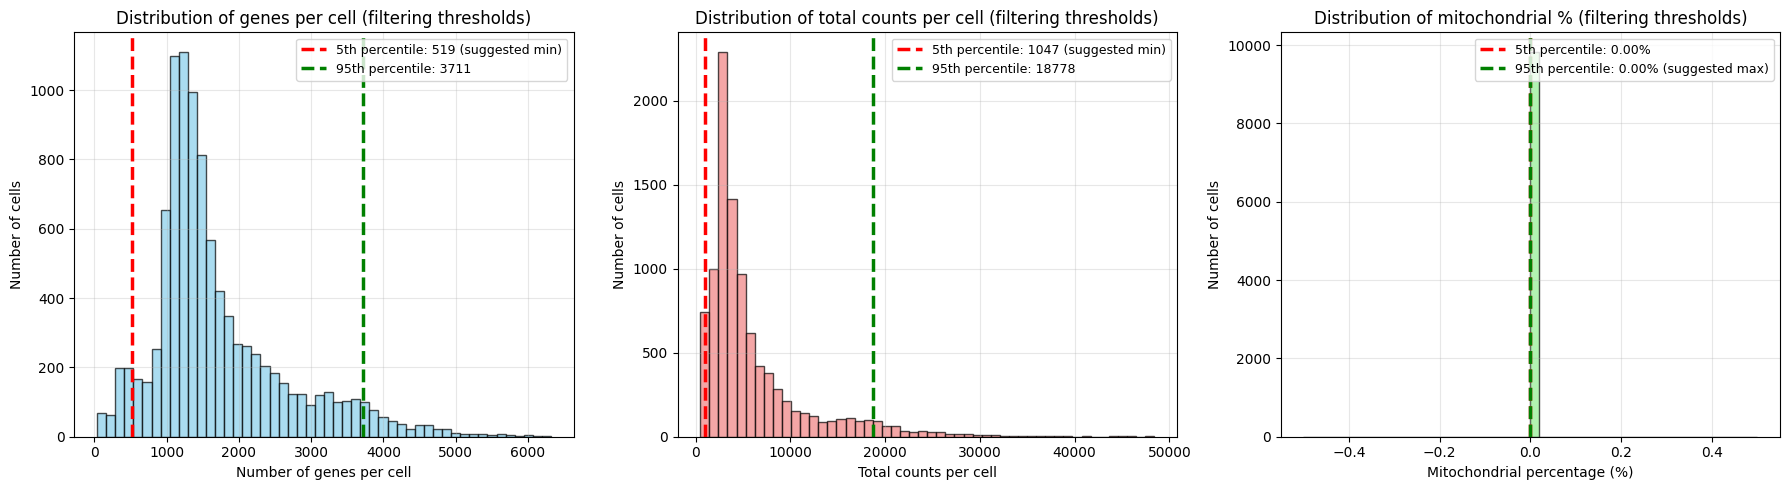

In [8]:
# Calculate quality control metrics for merged data
print("Calculating QC metrics for merged data...")
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Calculate percentiles for threshold detection (only 5th and 95th for filtering decisions)
n_genes_p5 = np.percentile(adata.obs['n_genes_by_counts'], 5)
n_genes_p95 = np.percentile(adata.obs['n_genes_by_counts'], 95)
total_counts_p5 = np.percentile(adata.obs['total_counts'], 5)
total_counts_p95 = np.percentile(adata.obs['total_counts'], 95)
mt_p5 = np.percentile(adata.obs['pct_counts_mt'], 5)
mt_p95 = np.percentile(adata.obs['pct_counts_mt'], 95)

# Generate diagnostic plots for merged data (SCENIC protocol style)
print("Generating pre-filtering diagnostic plots for merged data...\n")

# Plot 1: Histograms with 5th and 95th percentile markers (for filtering decisions)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram 1: Number of genes per cell
ax = axes[0]
ax.hist(adata.obs['n_genes_by_counts'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax.axvline(n_genes_p5, color='red', linestyle='--', linewidth=2.5, label=f'5th percentile: {n_genes_p5:.0f} (suggested min)')
ax.axvline(n_genes_p95, color='green', linestyle='--', linewidth=2.5, label=f'95th percentile: {n_genes_p95:.0f}')
ax.set_xlabel('Number of genes per cell')
ax.set_ylabel('Number of cells')
ax.set_title('Distribution of genes per cell (filtering thresholds)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Histogram 2: Total counts per cell
ax = axes[1]
ax.hist(adata.obs['total_counts'], bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
ax.axvline(total_counts_p5, color='red', linestyle='--', linewidth=2.5, label=f'5th percentile: {total_counts_p5:.0f} (suggested min)')
ax.axvline(total_counts_p95, color='green', linestyle='--', linewidth=2.5, label=f'95th percentile: {total_counts_p95:.0f}')
ax.set_xlabel('Total counts per cell')
ax.set_ylabel('Number of cells')
ax.set_title('Distribution of total counts per cell (filtering thresholds)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Histogram 3: Mitochondrial percentage
ax = axes[2]
ax.hist(adata.obs['pct_counts_mt'], bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
ax.axvline(mt_p5, color='red', linestyle='--', linewidth=2.5, label=f'5th percentile: {mt_p5:.2f}%')
ax.axvline(mt_p95, color='green', linestyle='--', linewidth=2.5, label=f'95th percentile: {mt_p95:.2f}% (suggested max)')
ax.set_xlabel('Mitochondrial percentage (%)')
ax.set_ylabel('Number of cells')
ax.set_title('Distribution of mitochondrial % (filtering thresholds)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'qc_plots_merged_prefiltering_histograms.png'), dpi=300, bbox_inches='tight')
plt.show()


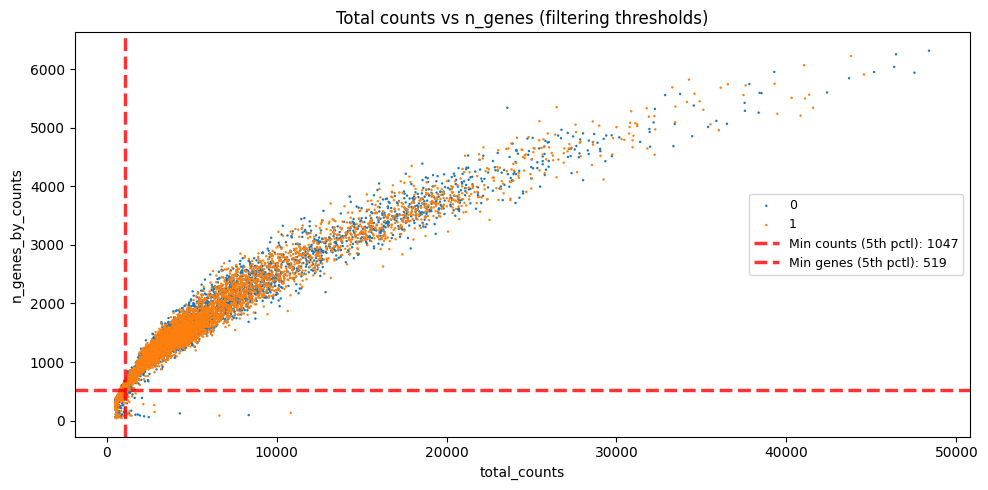

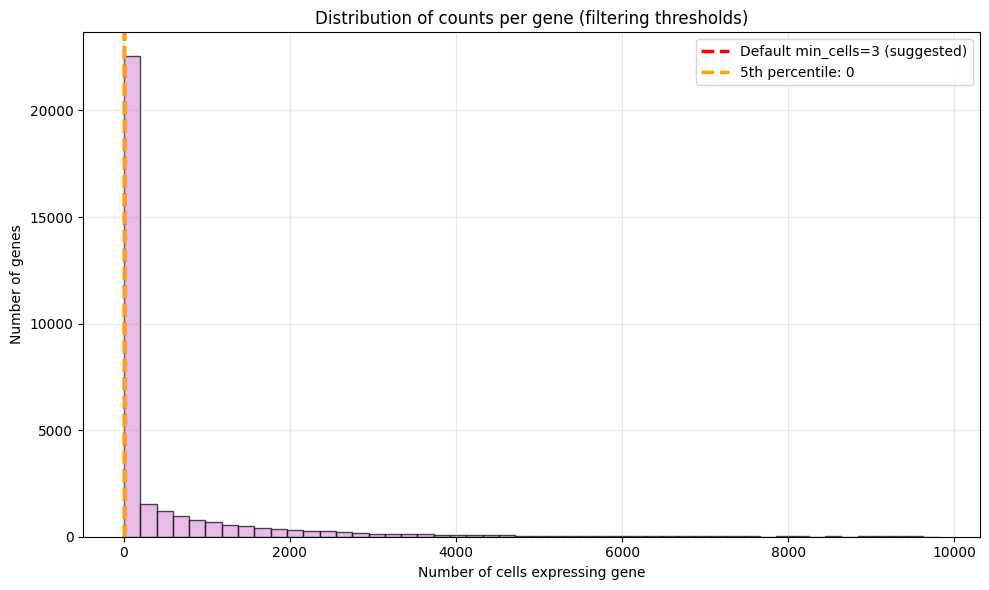

In [9]:
# Plot: Total counts vs n_genes (ONLY ONE PLOT)
fig, ax = plt.subplots(figsize=(10, 5))

sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='sample', ax=ax, show=False)
ax.axvline(total_counts_p5, color='red', linestyle='--', linewidth=2.5, alpha=0.8, label=f'Min counts (5th pctl): {total_counts_p5:.0f}')
ax.axhline(n_genes_p5, color='red', linestyle='--', linewidth=2.5, alpha=0.8, label=f'Min genes (5th pctl): {n_genes_p5:.0f}')
ax.set_title('Total counts vs n_genes (filtering thresholds)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'qc_merged_prefiltering_counts_vs_genes.png'), dpi=300, bbox_inches='tight')
plt.show()


# Plot 3: Distribution of counts per gene (for gene filtering)
gene_counts = np.array(np.sum(adata.X > 0, axis=0)).flatten()
gene_counts_p5 = np.percentile(gene_counts, 5)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.hist(gene_counts, bins=50, edgecolor='black', alpha=0.7, color='plum')
ax.axvline(3, color='red', linestyle='--', linewidth=2.5, label=f'Default min_cells=3 (suggested)')
ax.axvline(gene_counts_p5, color='orange', linestyle='--', linewidth=2.5, label=f'5th percentile: {gene_counts_p5:.0f}')
ax.set_xlabel('Number of cells expressing gene')
ax.set_ylabel('Number of genes')
ax.set_title('Distribution of counts per gene (filtering thresholds)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'qc_plots_merged_prefiltering_gene_counts.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 5: Filtering Steps

Apply quality control filters with default values. Adjust these thresholds based on the diagnostic plots above.

**Two types of filtering:**
1. **Cell filtering** (removes low-quality cells): Based on genes per cell, total counts per cell, and mitochondrial %
2. **Gene filtering** (removes noise genes): Based on how many cells express each gene (`min_cells_per_gene`)

Both are important:
- **Cell filtering** removes damaged/empty cells that have very few genes or counts
- **Gene filtering** removes genes expressed in too few cells (likely technical noise or artifacts)


In [10]:
# Apply filtering with default values
print(f"Before filtering: ")
print(f"  Cells: {adata.n_obs}, Genes: {adata.n_vars}\n")

print("=== CELL FILTERING (removes low-quality cells) ===")
print("Based on: genes per cell, total counts per cell, mitochondrial %\n")

# Filter 1: Minimum genes per cell (from histogram plot 1)
min_genes_per_cell = int(n_genes_p5)  # 5th percentile from diagnostic plots
print(f"1. Filtering cells with < {min_genes_per_cell} genes per cell...")
print(f"   Before: {adata.n_obs} cells")
sc.pp.filter_cells(adata, min_genes=min_genes_per_cell)
print(f"   After: {adata.n_obs} cells ({adata_mouse1.n_obs + adata_mouse2.n_obs - adata.n_obs} cells removed)")

# No mithodoncrial genes filtering, since there are none in this case

print(f"\n=== GENE FILTERING (removes noise genes) ===")
print("Based on: how many cells express each gene")
print(f"Before: {adata.n_vars} genes")

# Filter genes: minimum cells expressing each gene
min_cells_per_gene = 3  # Default value
print(f"Filtering genes expressed in < {min_cells_per_gene} cells...")
sc.pp.filter_genes(adata, min_cells=min_cells_per_gene)
print(f"After: {adata.n_vars} genes ({adata_mouse1.n_vars + adata_mouse2.n_vars - adata.n_vars} genes removed)")


print(f"\n=== FILTERING SUMMARY ===")
print(f"Final filtered data shape: {adata.shape}")
print(f"  Cells: {adata.n_obs} (removed {adata_mouse1.n_obs + adata_mouse2.n_obs - adata.n_obs})")
print(f"  Genes: {adata.n_vars} (removed {adata_mouse1.n_vars + adata_mouse2.n_vars - adata.n_vars})")


Before filtering: 
  Cells: 9834, Genes: 32285

=== CELL FILTERING (removes low-quality cells) ===
Based on: genes per cell, total counts per cell, mitochondrial %

1. Filtering cells with < 518 genes per cell...
   Before: 9834 cells
   After: 9347 cells (487 cells removed)

=== GENE FILTERING (removes noise genes) ===
Based on: how many cells express each gene
Before: 32285 genes
Filtering genes expressed in < 3 cells...
After: 17068 genes (47502 genes removed)

=== FILTERING SUMMARY ===
Final filtered data shape: (9347, 17068)
  Cells: 9347 (removed 487)
  Genes: 17068 (removed 47502)


## Step 6: Generate Diagnostic Plots (Post-filtering)

Generate the same diagnostic plots after filtering to assess the impact of filtering.


Generating post-filtering diagnostic plots...


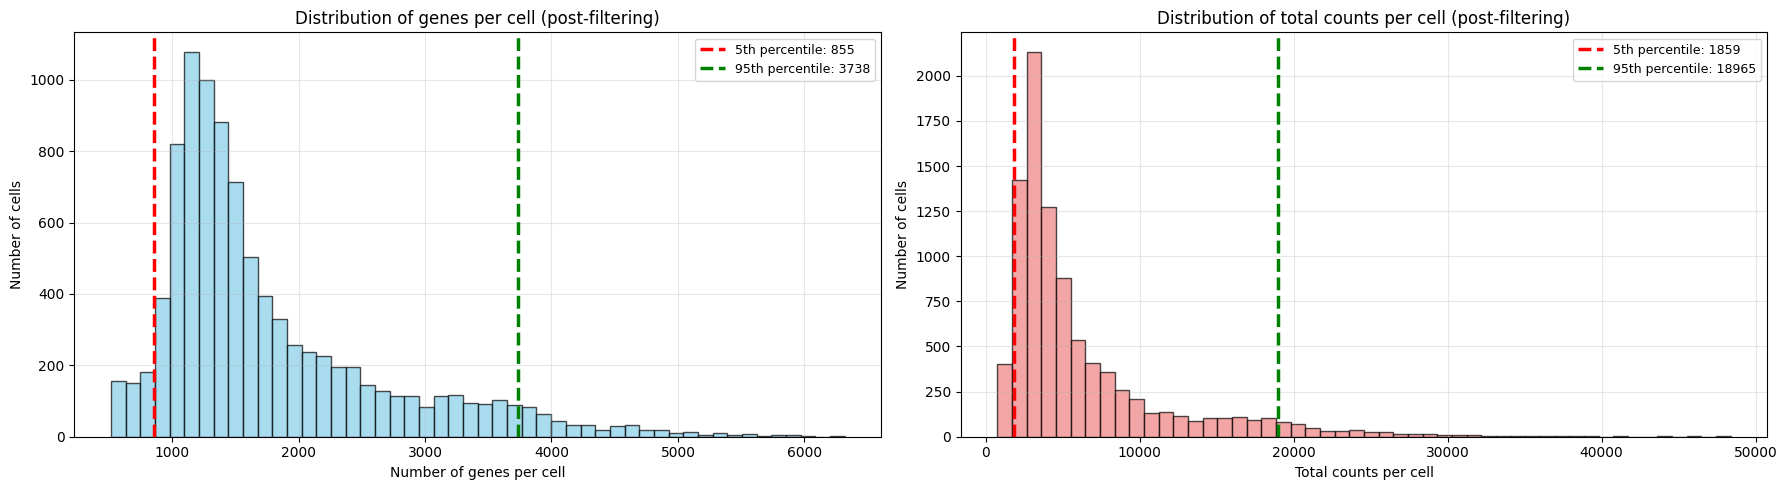

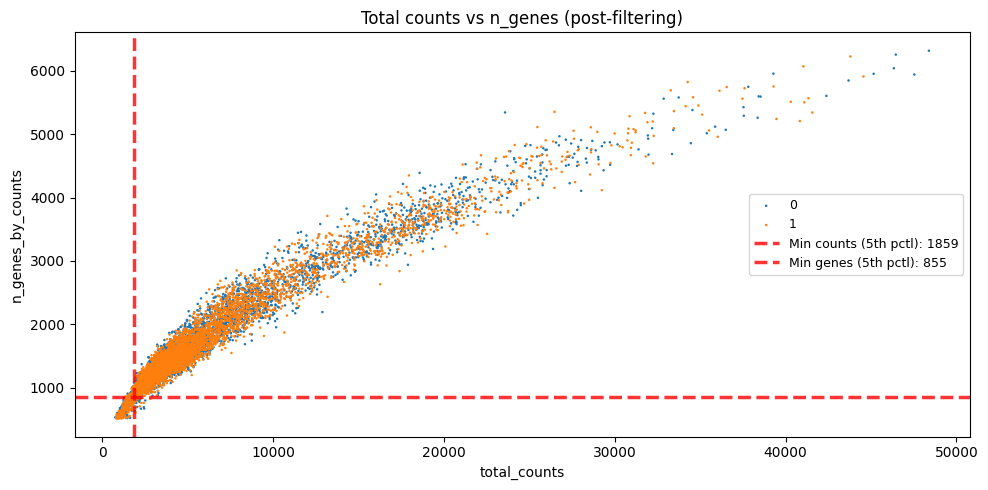

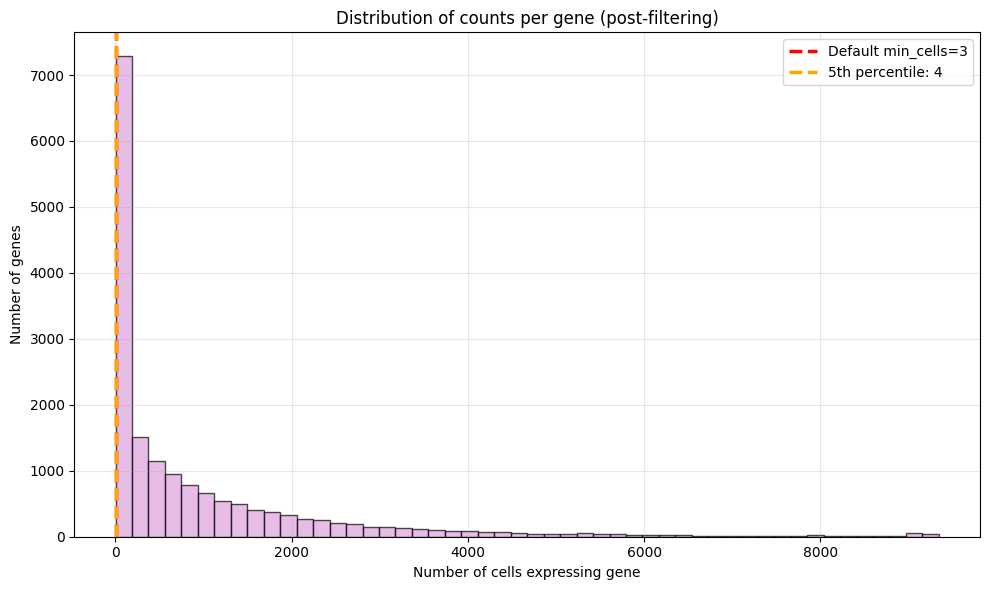

In [11]:
# Generate post-filtering diagnostic plots (matching pre-filtering style for comparison)
print("Generating post-filtering diagnostic plots...")

# Calculate percentiles for post-filtering data (5th and 95th for comparison)
n_genes_p5_post = np.percentile(adata.obs['n_genes_by_counts'], 5)
n_genes_p95_post = np.percentile(adata.obs['n_genes_by_counts'], 95)
total_counts_p5_post = np.percentile(adata.obs['total_counts'], 5)
total_counts_p95_post = np.percentile(adata.obs['total_counts'], 95)
mt_p5_post = np.percentile(adata.obs['pct_counts_mt'], 5)
mt_p95_post = np.percentile(adata.obs['pct_counts_mt'], 95)

# Plot 1: Histograms with 5th and 95th percentile markers (matching pre-filtering style)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Histogram 1: Number of genes per cell
ax = axes[0]
ax.hist(adata.obs['n_genes_by_counts'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax.axvline(n_genes_p5_post, color='red', linestyle='--', linewidth=2.5, label=f'5th percentile: {n_genes_p5_post:.0f}')
ax.axvline(n_genes_p95_post, color='green', linestyle='--', linewidth=2.5, label=f'95th percentile: {n_genes_p95_post:.0f}')
ax.set_xlabel('Number of genes per cell')
ax.set_ylabel('Number of cells')
ax.set_title('Distribution of genes per cell (post-filtering)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Histogram 2: Total counts per cell
ax = axes[1]
ax.hist(adata.obs['total_counts'], bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
ax.axvline(total_counts_p5_post, color='red', linestyle='--', linewidth=2.5, label=f'5th percentile: {total_counts_p5_post:.0f}')
ax.axvline(total_counts_p95_post, color='green', linestyle='--', linewidth=2.5, label=f'95th percentile: {total_counts_p95_post:.0f}')
ax.set_xlabel('Total counts per cell')
ax.set_ylabel('Number of cells')
ax.set_title('Distribution of total counts per cell (post-filtering)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'qc_plots_merged_postfiltering_histograms.png'), dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Scatter plots with threshold lines (matching pre-filtering style)
fig, ax = plt.subplots(figsize=(10, 5))

# Scatter 2: Total counts vs n_genes
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='sample', ax=ax, show=False)
ax.axvline(total_counts_p5_post, color='red', linestyle='--', linewidth=2.5, alpha=0.8, label=f'Min counts (5th pctl): {total_counts_p5_post:.0f}')
ax.axhline(n_genes_p5_post, color='red', linestyle='--', linewidth=2.5, alpha=0.8, label=f'Min genes (5th pctl): {n_genes_p5_post:.0f}')
ax.set_title('Total counts vs n_genes (post-filtering)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'qc_merged_postfiltering_counts_vf_genes.png'), dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Distribution of counts per gene (matching pre-filtering style)
gene_counts_filtered = np.array(np.sum(adata.X > 0, axis=0)).flatten()
gene_counts_p5_post = np.percentile(gene_counts_filtered, 5)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.hist(gene_counts_filtered, bins=50, edgecolor='black', alpha=0.7, color='plum')
ax.axvline(3, color='red', linestyle='--', linewidth=2.5, label=f'Default min_cells=3')
ax.axvline(gene_counts_p5_post, color='orange', linestyle='--', linewidth=2.5, label=f'5th percentile: {gene_counts_p5_post:.0f}')
ax.set_xlabel('Number of cells expressing gene')
ax.set_ylabel('Number of genes')
ax.set_title('Distribution of counts per gene (post-filtering)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'qc_plots_merged_postfiltering_gene_counts.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 7: Output Filtered Data to Loom Cleaned File

Write the filtered/cleaned data to a loom file for downstream analysis.


In [ ]:
# Define output file path for cleaned loom file
f_loom_cleaned = os.path.join(output_dir, "merged_cleaned.loom")

# Write filtered/cleaned data to loom file
print(f"Writing filtered data to: {f_loom_cleaned}")

row_attrs_cleaned = {
    "Gene": np.array(adata.var.index),
}

col_attrs_cleaned = {
    "CellID": np.array(adata.obs.index),
    "sample": np.array(adata.obs['sample']),
    "mouse": np.array(adata.obs['mouse']),
    "nGene": np.array(np.sum(adata.X > 0, axis=1)).flatten(),
    "nUMI": np.array(np.sum(adata.X, axis=1)).flatten(),
}

lp.create(f_loom_cleaned, adata.X.transpose(), row_attrs_cleaned, col_attrs_cleaned)
print(f"Created cleaned loom file: {f_loom_cleaned}")
print(f"Cleaned loom file shape: {adata.X.transpose().shape} (genes x cells)")


## Step 8: Normalize Pre-filtered Loom File

Normalize the filtered expression data. This step prepares the data for dimensionality reduction and clustering.


In [ ]:
# After this step, adata.X will contain NORMALIZED data used for downstream analyses (PCA, UMAP, clustering)
# Raw counts are preserved in adata.raw (needed for SCENIC analysis)

print("=== Normalization and Preprocessing ===\n")
print(f"Before normalization: {adata.shape}")

# Save a copy of the TRUE raw counts (needed for PySCENIC)
adata.raw = adata.copy()

# Normalize to 10k counts per cell (using current scanpy function)
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform (log(x+1))
# This stabilizes variance and makes data more suitable for downstream analysis
sc.pp.log1p(adata)

# genes with high variance across cells, useful for dimensionality reduction
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata, show=False)
plt.savefig(os.path.join(output_dir, 'highly_variable_genes.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Subset to HVGs only (reduces dimensionality and noise)
adata = adata[:, adata.var['highly_variable']]

# Regress out total counts (removes technical variation)
# This helps remove sequencing depth effects
sc.pp.regress_out(adata, ['total_counts'])

# Scale the data to unit variance (z-score normalization)
# This ensures all genes have equal weight in downstream analysis
sc.pp.scale(adata, max_value=10)

# Write the processed AnnData object
adata.write(f_anndata_path)
print(f"\n✓ Saved processed AnnData object to: {f_anndata_path}")


## Step 9: Perform PCA, UMAP and Clustering

Perform dimensionality reduction and clustering analysis.


Performing PCA...


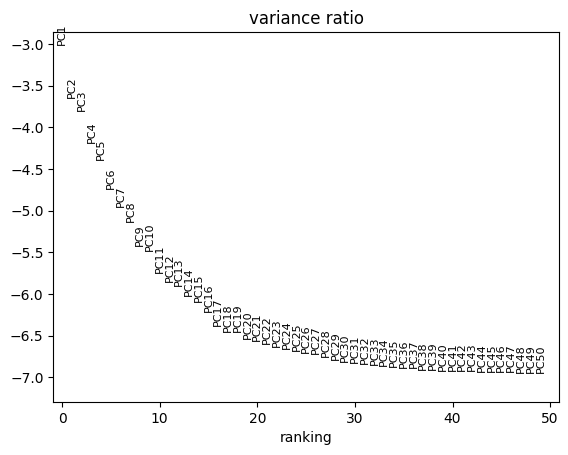

In [14]:
# Principal component analysis
print("Performing PCA...")
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50, show=False)
plt.savefig(os.path.join(output_dir, 'pca_variance_ratio.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()


In [15]:
# Determine number of PCs to use (inspect the plot above)
# TODO: Adjust n_pcs based on elbow in variance plot
n_pcs = 25
print(f"Using {n_pcs} principal components")

# Construct neighborhood graph
print("Constructing neighborhood graph...")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=n_pcs)

# Compute UMAP embedding
print("Computing UMAP embedding...")
sc.tl.umap(adata)


Using 25 principal components
Constructing neighborhood graph...
Computing UMAP embedding...


In [ ]:
# Perform clustering
# TODO: Test different resolutions to find appropriate granularity
print("Performing clustering...")

# Ensure neighbors graph exists and is properly computed
if 'neighbors' not in adata.uns:
    print("Warning: neighbors graph not found. Recomputing...")
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=n_pcs)

# Use Leiden algorithm for clustering
sc.tl.leiden(adata, resolution=0.5)

# Visualize clusters
sc.pl.umap(adata, color=['leiden'], legend_loc='on data', title='Leiden clusters', show=False)
plt.savefig(os.path.join(output_dir, 'umap_clusters.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Visualize by sample to check for batch effects
sc.pl.umap(adata, color=['sample'], title='UMAP colored by sample', show=False)
plt.savefig(os.path.join(output_dir, 'umap_by_sample.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Save intermediate results
adata.write(f_anndata_path)
print(f"\nSaved AnnData object to: {f_anndata_path}")
print(f"Final processed data shape: {adata.shape}")
print(f"Number of clusters: {adata.obs['leiden'].nunique()}")


## Step 10: Check for Batch Effects

Assess whether batch effects are present in the data by examining sample distribution across clusters and UMAP space.


In [17]:
# Check for batch effects
print("=== Batch Effect Assessment ===\n")

# 1. Sample distribution across clusters
print("1. Sample distribution across clusters:")
cluster_sample = pd.crosstab(adata.obs['leiden'], adata.obs['sample'], normalize='index') * 100
print(cluster_sample.round(2))
print()

# 2. Statistical test for batch effects (chi-square test)
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(adata.obs['leiden'], adata.obs['sample'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"2. Chi-square test for independence:")
print(f"   Chi-square statistic: {chi2:.2f}")
print(f"   p-value: {p_value:.2e}")
print(f"   Degrees of freedom: {dof}")
if p_value < 0.05:
    print("   → Significant association detected (potential batch effect)")
else:
    print("   → No significant association detected")
print()

# 3. Check for sample-specific clusters
print("3. Clusters with strong sample bias (>80% from one sample):")
for cluster in adata.obs['leiden'].unique():
    cluster_data = adata.obs[adata.obs['leiden'] == cluster]
    sample_counts = cluster_data['sample'].value_counts(normalize=True) * 100
    max_sample_pct = sample_counts.max()
    if max_sample_pct > 80:
        max_sample = sample_counts.idxmax()
        print(f"   Cluster {cluster}: {max_sample_pct:.1f}% from {max_sample}")
print()

# 4. Visualize QC metrics by sample
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             groupby='sample', jitter=0.4, multi_panel=True, show=False)
plt.savefig(os.path.join(output_dir, 'batch_effect_qc_by_sample.png'), dpi=300, bbox_inches='tight')
plt.close()



# 5. Summary
print("4. Summary:")
print(f"   Total cells: {adata.n_obs}")
# Check actual sample values instead of variable names
sample_counts = adata.obs['sample'].value_counts()
for sample_val, count in sample_counts.items():
    print(f"   Cells from sample {sample_val}: {count}")
print(f"   Number of clusters: {adata.obs['leiden'].nunique()}")
print()

print("=== Batch Effect Assessment Complete ===")
print("\nIf batch effects are detected, consider applying batch correction methods:")
print("  - scvi-tools (scvi.model.SCVI) - recommended for complex batch effects")
print("  - Harmony (scanpy.external.pp.harmony_integrate) - fast and effective")
print("  - scanpy's pp.combat - simple linear correction")


=== Batch Effect Assessment ===

1. Sample distribution across clusters:
sample      0      1
leiden              
0       46.94  53.06
1       46.69  53.31
2       47.35  52.65
3       47.92  52.08
4       46.34  53.66
5       43.10  56.90
6       46.49  53.51
7       49.75  50.25
8       47.38  52.62
9       45.36  54.64
10      39.32  60.68
11      48.00  52.00
12      56.76  43.24
13      34.25  65.75
14      36.67  63.33
15      44.83  55.17

2. Chi-square test for independence:
   Chi-square statistic: 20.54
   p-value: 1.52e-01
   Degrees of freedom: 15
   → No significant association detected

3. Clusters with strong sample bias (>80% from one sample):

4. Summary:
   Total cells: 9347
   Cells from sample 1: 4993
   Cells from sample 0: 4354
   Number of clusters: 16

=== Batch Effect Assessment Complete ===

If batch effects are detected, consider applying batch correction methods:
  - scvi-tools (scvi.model.SCVI) - recommended for complex batch effects
  - Harmony (scanpy.ex

## Step 11: Find Marker Genes

Identify marker genes for each cluster using differential expression analysis. This step helps:
- **Validate clustering quality**: Marker genes should be biologically meaningful
- **Interpret clusters**: Understand what cell types or states each cluster represents
- **Guide SCENIC interpretation**: Marker genes can help interpret regulon activity patterns

**Note**: This step is recommended in the SCENIC protocol before proceeding to SCENIC analysis (Step 1: GRNBoost2).


In [ ]:
# Find marker genes for each cluster
# t-test (recommended for most cases - fast and standard)
print("Identifying marker genes for each cluster using t-test...")
print(f"Using clustering: 'leiden' with {adata.obs['leiden'].nunique()} clusters\n")

# Create normalized data with ALL genes (not just HVGs) from raw counts for marker identification
# This allows us to find markers using all genes, not just the highly variable ones
adata.normalized = adata.raw.to_adata()

# Normalize and log transform
sc.pp.normalize_total(adata.normalized, target_sum=1e4)
sc.pp.log1p(adata.normalized)

# Copy clustering information from adata to adata.normalized
# Clustering was done on adata (after HVG filtering), but we need it in adata.normalized to identify markers using all genes
adata.normalized.obs['leiden'] = adata.obs['leiden'].values

# Use normalized data with ALL genes with same clustering as adata
sc.tl.rank_genes_groups(adata.normalized, 'leiden', method='t-test', use_raw=False)

# Visualize top marker genes
print("Plotting top 25 marker genes per cluster (t-test)...")
sc.pl.rank_genes_groups(adata.normalized, n_genes=25, sharey=False, show=False)
plt.savefig(os.path.join(output_dir, 'marker_genes_ranked_ttest.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Display and save top 10 marker genes per cluster
print("\nTop 25 marker genes per cluster (t-test):")
marker_genes_ttest = pd.DataFrame(adata.normalized.uns['rank_genes_groups']['names']).head(25)
print(marker_genes_ttest)
marker_genes_ttest.to_csv(os.path.join(output_dir, 'marker_genes_top25_per_cluster_ttest.csv'))
print(f"✓ Saved t-test marker genes to: {os.path.join(output_dir, 'marker_genes_top25_per_cluster_ttest.csv')}\n")

# Save the AnnData object with marker gene information
adata.write(f_anndata_path)
print(f"✓ Saved AnnData object with marker genes to: {f_anndata_path}")
print("\n=== Marker Gene Identification Complete ===")


## Next Steps: SCENIC Analysis

**Preprocessing is complete!**

The following output files have been generated:
- `pre_processing_results/processed_adata.h5ad` - Processed AnnData object with clustering and UMAP
- `pre_processing_results/merged_cleaned.loom` - Filtered loom file for SCENIC analysis

**To continue with SCENIC analysis**, please proceed to `pySCENIC-processing.ipynb`. That notebook will:
- Run GRNBoost2 for gene regulatory network inference
- Run cisTarget for regulon prediction
- Run AUCell for regulon activity scoring
- Calculate RSS (Regulon Specificity Scores)
- Integrate results with the preprocessed data

**Note**: SCENIC analysis requires additional databases from [https://resources.aertslab.org/cistarget/](https://resources.aertslab.org/cistarget/).


In [19]:
# Session info
sc.logging.print_versions()


-----
anndata     0.8.0
scanpy      1.9.1
-----
PIL                         9.3.0
anyio                       NA
arrow                       1.3.0
asttokens                   NA
attr                        25.3.0
attrs                       25.3.0
babel                       2.17.0
backcall                    0.2.0
certifi                     2022.09.24
cffi                        1.15.1
charset_normalizer          2.1.1
cloudpickle                 2.2.0
cycler                      0.10.0
cython_runtime              NA
cytoolz                     0.12.0
dask                        2022.11.1
dateutil                    2.8.2
debugpy                     1.6.3
decorator                   5.1.1
defusedxml                  0.7.1
entrypoints                 0.4
exceptiongroup              1.2.2
executing                   1.2.0
fastjsonschema              NA
fqdn                        NA
fsspec                      2022.11.0
h5py                        3.7.0
idna                        3.4
